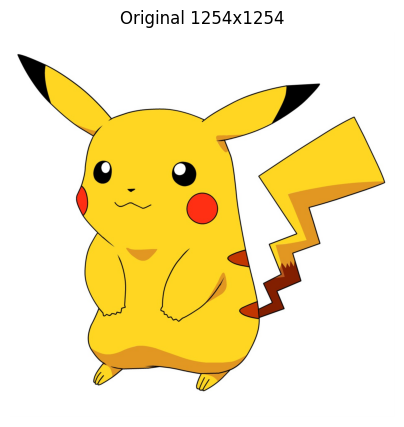

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

img = cv2.imread("INPUT/img03.jpg")
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.axis("off")
plt.title(f"Original {img.shape[1]}x{img.shape[0]}")
plt.show()

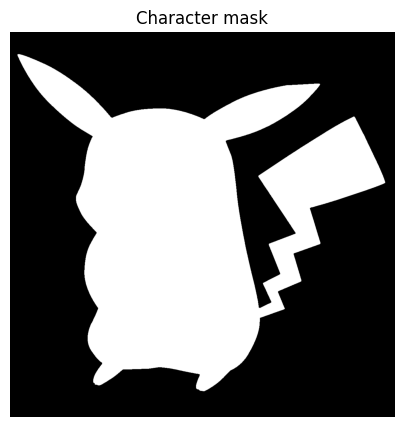

In [2]:
# Маска персонажа: всё что не белый фон
gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
_, mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)

# Убираем мелкий мусор
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)

# Оставляем только самый большой контур
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_clean = np.zeros_like(mask)
biggest = max(contours, key=cv2.contourArea)
cv2.drawContours(mask_clean, [biggest], -1, 255, cv2.FILLED)

plt.figure(figsize=(5, 5))
plt.imshow(mask_clean, cmap="gray")
plt.axis("off")
plt.title("Character mask")
plt.show()

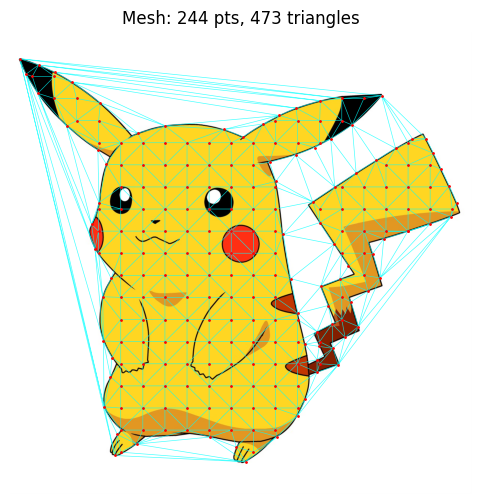

In [3]:
from scipy.spatial import Delaunay

# Точки по контуру (прореживаем)
contour_pts = biggest.squeeze()
step = max(1, len(contour_pts) // 80)
sparse_contour = contour_pts[::step]

# Точки внутри маски (регулярная сетка)
grid_step = 60
ys, xs = np.where(mask_clean > 0)
grid_pts = []
for x in range(0, img.shape[1], grid_step):
    for y in range(0, img.shape[0], grid_step):
        if mask_clean[y, x] > 0:
            grid_pts.append([x, y])
grid_pts = np.array(grid_pts)

# Объединяем все точки
all_pts = np.vstack([sparse_contour, grid_pts])

# Триангуляция
tri = Delaunay(all_pts)

# Визуализация
plt.figure(figsize=(6, 6))
plt.imshow(img)
plt.triplot(all_pts[:, 0], all_pts[:, 1], tri.simplices, color="cyan", linewidth=0.5, alpha=0.7)
plt.plot(all_pts[:, 0], all_pts[:, 1], "r.", markersize=2)
plt.axis("off")
plt.title(f"Mesh: {len(all_pts)} pts, {len(tri.simplices)} triangles")
plt.show()


In [7]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("INPUT/img03.jpg")

HANDLE_NAMES = [
    "head",        # 0
    "left_ear",    # 1
    "right_ear",   # 2
    "left_hand",   # 3
    "right_hand",  # 4
    "left_foot",   # 5
    "right_foot",  # 6
    "tail_top",    # 7
    "tail_bottom", # 8
    "body_center", # 9 — якорь
]

WINDOW = "Handle Markup"
SCALE = 0.5  # масштаб окна

display = img.copy()
base = img.copy()
clicked = []

def redraw():
    global display
    display = base.copy()
    for i, pt in enumerate(clicked):
        cv2.circle(display, pt, 8, (0, 0, 255), -1)
        cv2.circle(display, pt, 8, (255, 255, 255), 2)
        cv2.putText(display, f"{i}:{HANDLE_NAMES[i]}", (pt[0]+12, pt[1]-5),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 200, 0), 2)
    n = len(clicked)
    total = len(HANDLE_NAMES)
    if n < total:
        txt = f"Click: {HANDLE_NAMES[n]} ({n}/{total}) | RMB=undo"
    else:
        txt = f"Done ({total}/{total})! Press any key"
    cv2.putText(display, txt, (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 180, 255), 2)

def on_mouse(event, x, y, flags, param):
    # Пересчитываем координаты из масштабированного окна в оригинал
    ox, oy = int(x / SCALE), int(y / SCALE)
    if event == cv2.EVENT_LBUTTONDOWN and len(clicked) < len(HANDLE_NAMES):
        clicked.append((ox, oy))
        redraw()
        cv2.imshow(WINDOW, cv2.resize(display, None, fx=SCALE, fy=SCALE))
    elif event == cv2.EVENT_RBUTTONDOWN and clicked:
        clicked.pop()
        redraw()
        cv2.imshow(WINDOW, cv2.resize(display, None, fx=SCALE, fy=SCALE))

redraw()
cv2.imshow(WINDOW, cv2.resize(display, None, fx=SCALE, fy=SCALE))
cv2.setMouseCallback(WINDOW, on_mouse)
cv2.waitKey(0)
cv2.destroyAllWindows()

handles = np.array(clicked, dtype=np.float64)
print(f"\nHandles ({len(handles)}):")
for i, (x, y) in enumerate(handles):
    print(f"  {i}: {HANDLE_NAMES[i]:16s} ({x:.0f}, {y:.0f})")



Handles (10):
  0: head             (430, 318)
  1: left_ear         (58, 98)
  2: right_ear        (976, 184)
  3: left_hand        (330, 882)
  4: right_hand       (554, 886)
  5: left_foot        (302, 1116)
  6: right_foot       (640, 1126)
  7: tail_top         (1110, 306)
  8: tail_bottom      (868, 890)
  9: body_center      (454, 762)


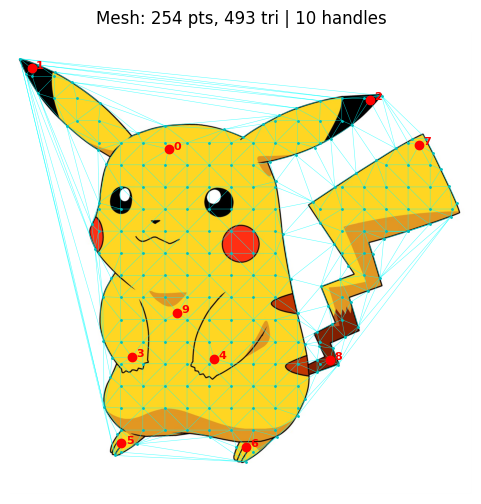

In [8]:
from scipy.spatial import Delaunay

# Маска персонажа
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
_, mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
mask_clean = np.zeros_like(mask)
biggest = max(contours, key=cv2.contourArea)
cv2.drawContours(mask_clean, [biggest], -1, 255, cv2.FILLED)

# Точки по контуру
contour_pts = biggest.squeeze()
step = max(1, len(contour_pts) // 80)
sparse_contour = contour_pts[::step]

# Точки внутри маски
grid_step = 60
grid_pts = []
for x in range(0, img.shape[1], grid_step):
    for y in range(0, img.shape[0], grid_step):
        if mask_clean[y, x] > 0:
            grid_pts.append([x, y])
grid_pts = np.array(grid_pts)

# Объединяем: handles + контур + сетка
all_pts = np.vstack([handles, sparse_contour, grid_pts])

# Триангуляция
tri = Delaunay(all_pts)

# Визуализация
fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
ax.triplot(all_pts[:, 0], all_pts[:, 1], tri.simplices, color="cyan", linewidth=0.4, alpha=0.6)
# Обычные точки
ax.plot(all_pts[len(handles):, 0], all_pts[len(handles):, 1], "c.", markersize=2)
# Handles — красным
ax.plot(handles[:, 0], handles[:, 1], "ro", markersize=6)
for i, (x, y) in enumerate(handles):
    ax.annotate(f"{i}", (x + 12, y), color="red", fontsize=8, fontweight="bold")
ax.axis("off")
ax.set_title(f"Mesh: {len(all_pts)} pts, {len(tri.simplices)} tri | {len(handles)} handles")
plt.show()


30/30
Saved: OUTPUT/img03_mesh_anim.gif


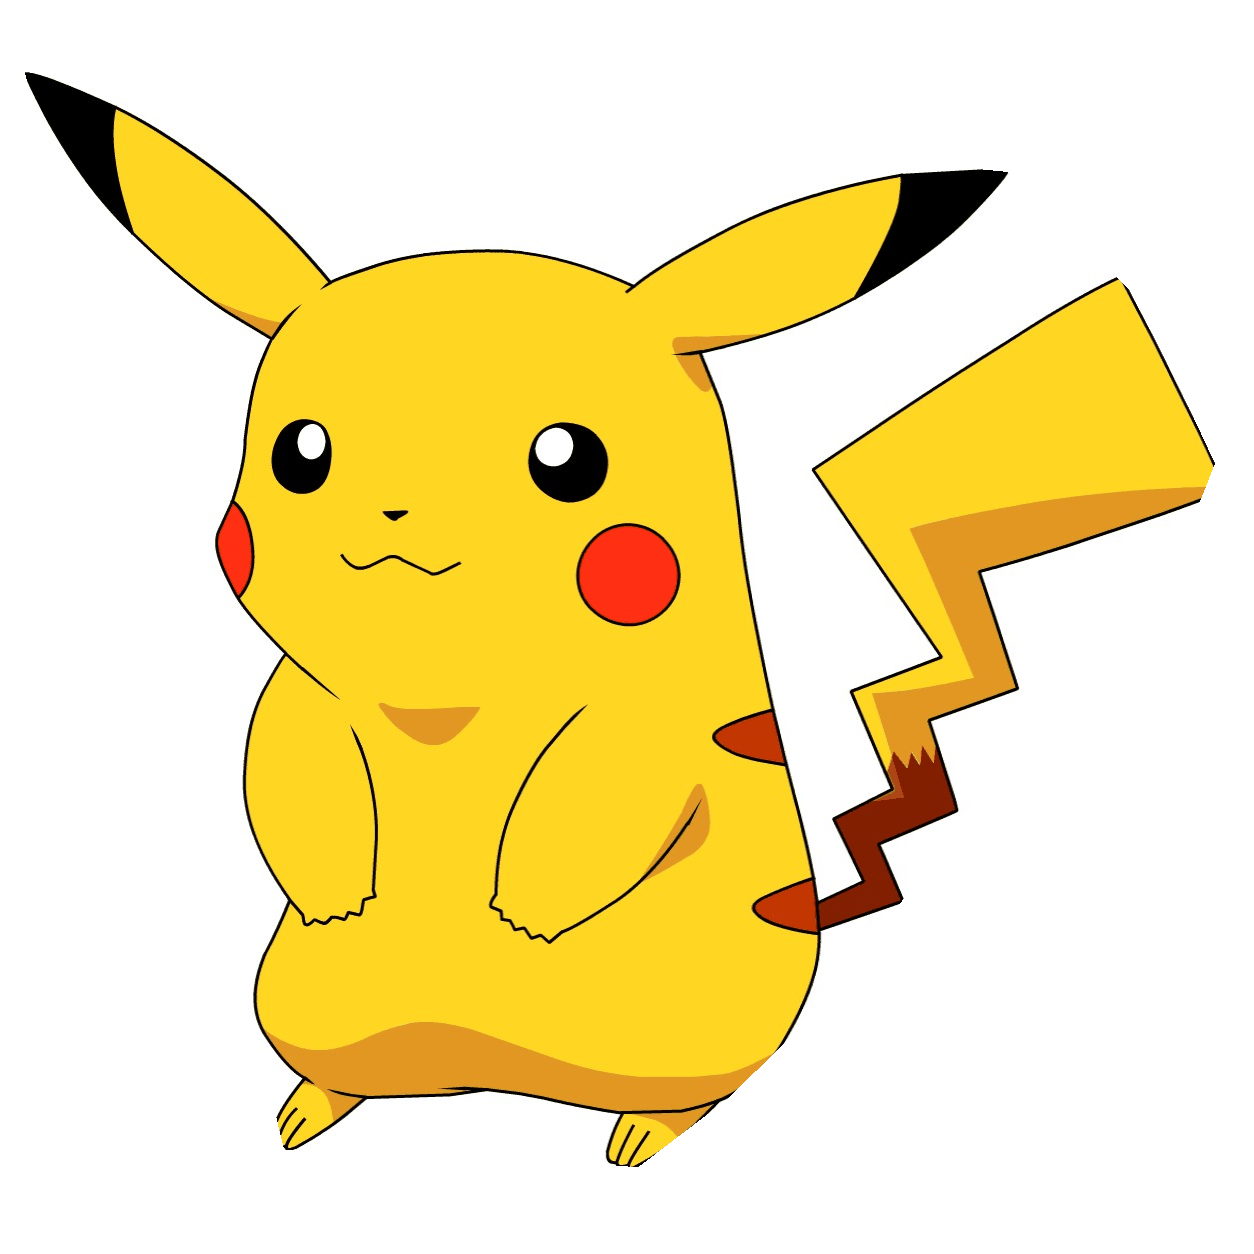

In [9]:
from scipy.interpolate import RBFInterpolator
from IPython.display import Image as IPImage, display

n_frames = 30
amplitude = 25

# Смещения handles на каждом кадре (синусоида)
def get_offsets(t):
    """t in [0, 2*pi]"""
    s = np.sin(t)
    offsets = np.zeros((len(handles), 2))
    offsets[0] = [0, -8 * s]                    # head: кивок
    offsets[1] = [-12 * s, -18 * s]             # left ear
    offsets[2] = [12 * s, -18 * s]              # right ear
    offsets[3] = [-amplitude * s, 0]            # left hand
    offsets[4] = [amplitude * s, 0]             # right hand
    offsets[5] = [-5 * s, 0]                    # left foot
    offsets[6] = [5 * s, 0]                     # right foot
    offsets[7] = [30 * s, -10 * s]              # tail top
    offsets[8] = [20 * np.sin(t + 0.5), 0]      # tail bottom
    offsets[9] = [0, 0]                         # body center — якорь
    return offsets

# Варп одного кадра
def warp_frame(img, pts_src, pts_dst, triangles):
    h, w = img.shape[:2]
    out = np.full_like(img, 255)
    for simplex in triangles:
        s = pts_src[simplex].astype(np.float32)
        d = pts_dst[simplex].astype(np.float32)
        # Bounding rect целевого треугольника
        rx, ry, rw, rh = cv2.boundingRect(d)
        if rw == 0 or rh == 0:
            continue
        x1, y1 = max(rx, 0), max(ry, 0)
        x2, y2 = min(rx + rw, w), min(ry + rh, h)
        if x2 <= x1 or y2 <= y1:
            continue
        d_off = d - np.array([x1, y1], dtype=np.float32)
        M = cv2.getAffineTransform(s, d_off)
        warped = cv2.warpAffine(img, M, (x2 - x1, y2 - y1))
        mask = np.zeros((y2 - y1, x2 - x1), dtype=np.uint8)
        cv2.fillConvexPoly(mask, d_off.astype(np.int32), 255)
        roi = out[y1:y2, x1:x2]
        roi[mask > 0] = warped[mask > 0]
    return out

# Генерим кадры
frames = []
for i in range(n_frames):
    t = 2 * np.pi * i / n_frames
    offsets = get_offsets(t)
    # RBF: интерполируем смещения handles → все точки меша
    rbf_x = RBFInterpolator(handles, offsets[:, 0], kernel="thin_plate_spline", smoothing=1)
    rbf_y = RBFInterpolator(handles, offsets[:, 1], kernel="thin_plate_spline", smoothing=1)
    all_offsets = np.column_stack([rbf_x(all_pts), rbf_y(all_pts)])
    pts_deformed = all_pts + all_offsets
    frame = warp_frame(img, all_pts, pts_deformed, tri.simplices)
    frames.append(frame)
    print(f"\r{i+1}/{n_frames}", end="")

# Сохраняем GIF
from PIL import Image
pil_frames = [Image.fromarray(cv2.cvtColor(f, cv2.COLOR_BGR2RGB)) for f in frames]
gif_path = "OUTPUT/img03_mesh_anim.gif"
pil_frames[0].save(gif_path, save_all=True, append_images=pil_frames[1:],
                   duration=1000 // 15, loop=0)
print(f"\nSaved: {gif_path}")
display(IPImage(filename=gif_path))
